In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])

0

In [2]:
import tensorflow as tf
print(tf.__version__)  # 예: 2.15.0

from tensorflow import keras
from tensorflow.keras import layers

2.21.0


In [3]:
# 3-1. Sequential API

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation="relu", input_shape=(4,)),  # 입력층 + 첫 번째 은닉층
    Dense(64, activation="relu"),                      # 두 번째 은닉층
    Dense(3, activation="softmax")                     # 출력층 (클래스 3개)
])


c:\Users\PDG\OneDrive\Desktop\PJ\CODE\Ai-practice\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# 3-3. 활성화 함수

# ReLU — 은닉층에서 가장 많이 쓰임
Dense(128, activation="relu")

# Sigmoid — 이진 분류 출력층 (0~1 사이 확률)
Dense(1, activation="sigmoid")

# Softmax — 다중 분류 출력층 (확률의 합 = 1)
Dense(10, activation="softmax")  # 10개 클래스

<Dense name=dense_5, built=False>

In [5]:
# 3-4. 모델 구조 확인

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,091 (35.51 KB)

 Trainable params: 9,091 (35.51 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 4-1. 컴파일 설정

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
# 데이터 준비 — 붓꽃(iris) 데이터셋 (input_shape=(4,), 클래스 3개에 맞춤)
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

X_train: (120, 4), y_train: (120,)


In [8]:
# 4-4. 모델 학습

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.3542 - loss: 1.0090 - val_accuracy: 0.5000 - val_loss: 0.9709
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6458 - loss: 0.9099 - val_accuracy: 0.8333 - val_loss: 0.8425
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8438 - loss: 0.8264 - val_accuracy: 0.9583 - val_loss: 0.7746
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7708 - loss: 0.7541 - val_accuracy: 0.5833 - val_loss: 0.7361
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6979 - loss: 0.6950 - val_accuracy: 0.5833 - val_loss: 0.6988
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6875 - loss: 0.6492 - val_accuracy: 0.5833 - val_loss: 0.6578
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6875 - loss: 0.6136 - val_accuracy: 0.5833 - val_loss: 0.6239
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6875 - loss: 0.5749 - val_accuracy: 0.7083 - val_loss: 0.5723


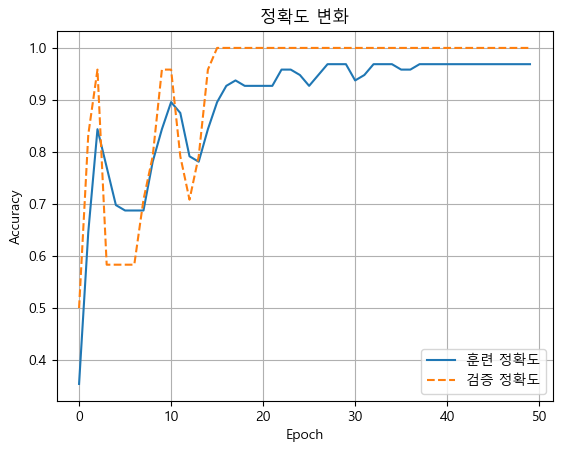

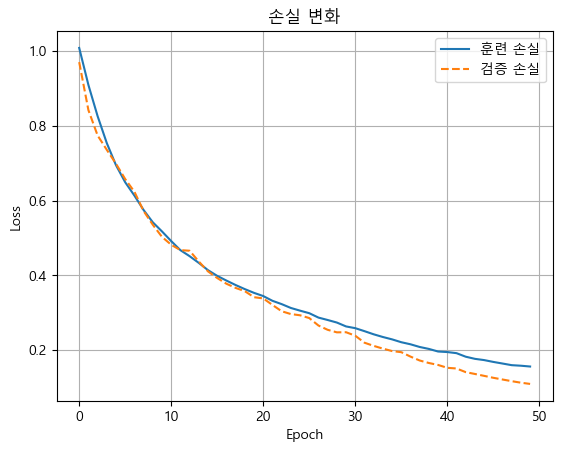

In [9]:
# 4-5. 학습 곡선 시각화

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

plt.plot(history.history["accuracy"],     label="훈련 정확도")
plt.plot(history.history["val_accuracy"], label="검증 정확도", linestyle="--")
plt.title("정확도 변화")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history["loss"],     label="훈련 손실")
plt.plot(history.history["val_loss"], label="검증 손실", linestyle="--")
plt.title("손실 변화")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(60000,)


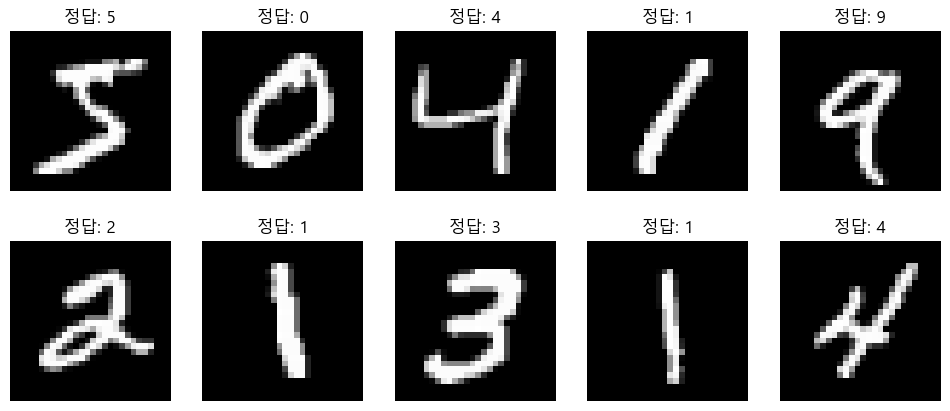

(60000, 784)


In [10]:
# 5-2. MNIST  데이터 전처리

from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)  # (60000, 28, 28)
print(y_train.shape)  # (60000,)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(f"정답: {y_train[i]}")
    ax.axis("off")
plt.show()

# 정규화
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Flatten
X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

print(X_train.shape)  # (60000, 784)

In [11]:
# 5-3. 모델 설계 및 학습

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

model.summary()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

c:\Users\PDG\OneDrive\Desktop\PJ\CODE\Ai-practice\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8882 - loss: 0.3668 - val_accuracy: 0.9588 - val_loss: 0.1396
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9501 - loss: 0.1668 - val_accuracy: 0.9663 - val_loss: 0.1072
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9620 - loss: 0.1254 - val_accuracy: 0.9710 - val_loss: 0.0935
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9685 - loss: 0.1023 - val_accuracy: 0.9743 - val_loss: 0.0876
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9735 - loss: 0.0871 - val_accuracy: 0.9756 - val_loss: 0.0832
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9767 - loss: 0.0767 - val_accuracy: 0.9757 - val_loss: 0.0856
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9774 - loss: 0.0718 - val_accuracy: 0.9780 - val_loss: 0.0822
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9800 - loss: 0.0617 - val_accuracy: 0.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step


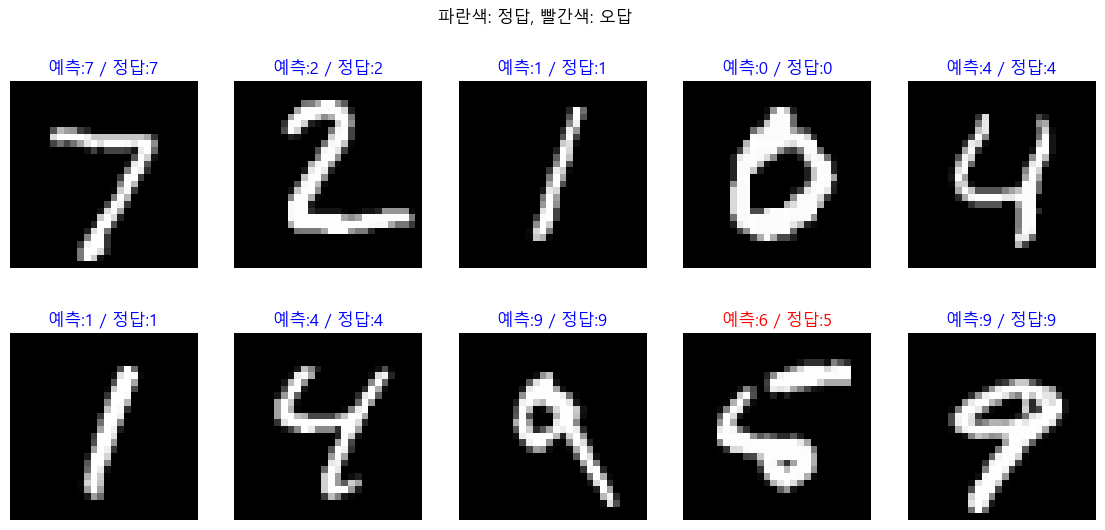

In [12]:
# 5-4. 예측 결과 시각화
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

y_pred_proba = model.predict(X_test)
y_pred       = np.argmax(y_pred_proba, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")
    color = "blue" if y_pred[i] == y_test[i] else "red"
    ax.set_title(f"예측:{y_pred[i]} / 정답:{y_test[i]}", color=color)
    ax.axis("off")

plt.suptitle("파란색: 정답, 빨간색: 오답")
plt.show()

In [13]:
# 5-5. 정확도 확인
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"테스트 정확도: {test_acc:.4f}")  # 예: 0.9789 (97.89%)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step - accuracy: 0.9790 - loss: 0.0812
테스트 정확도: 0.9790


In [14]:
# 6-2. Dropout

from tensorflow.keras.layers import Dropout

Dropout(0.3)  # 30%의 뉴런을 랜덤으로 비활성화
# 예측할 때는 모든 뉴런이 다시 켜집니다

<Dropout name=dropout_2, built=True>

In [15]:
# 6-3. EarlyStopping

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stop]
)

print(f"실제 학습된 에폭 수: {len(history.history['loss'])}")

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9834 - loss: 0.0539 - val_accuracy: 0.9779 - val_loss: 0.0944
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9849 - loss: 0.0465 - val_accuracy: 0.9783 - val_loss: 0.0913
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9862 - loss: 0.0435 - val_accuracy: 0.9798 - val_loss: 0.0926
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9858 - loss: 0.0446 - val_accuracy: 0.9800 - val_loss: 0.0883
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9868 - loss: 0.0411 - val_accuracy: 0.9806 - val_loss: 0.0828
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9868 - loss: 0.0412 - val_accuracy: 0.9804 - val_loss: 0.0893
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9864 - loss: 0.0428 - val_accuracy: 0.9803 - val_loss: 0.0939
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9880 - loss: 0

In [16]:
# 7-1. 모델 저장

model.save("mnist_model.keras")

In [17]:
# 7-2. 모델 불러오기

from tensorflow.keras.models import load_model

loaded_model = load_model("mnist_model.keras")

y_pred = loaded_model.predict(X_test)
print(f"정확도: {loaded_model.evaluate(X_test, y_test)[1]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 701us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step - accuracy: 0.9812 - loss: 0.0736
정확도: 0.9812
